In [ ]:
# Practica de Carlos Salas Alarcón
# Grupo 2 de Prácticas,Ing. de IA

# CADENAS DE MARKOV

## Introducción

### Ejemplo 1

Cuando Cj está triste, lo que no es muy habitual: o sale a correr, o se zampa un helado o se echa una siesta. Por los datos históricos, si pasó durmiendo un día triste, al día siguiente hay un 60% de probabilidades de que salga a correr, un 20% de que se quede en la cama y un 20% de que se coma un helado. Cuando está triste y sale a correr, hay un 60% de probabilidades de que salga a correr al día siguiente, un 30% de que se atiborre de helado y sólo un 10% de probabilidades de que pase durmiendo al día siguiente. Por último, cuando se da un capricho con un helado en un día triste, sólo hay un 10% de probabilidades de que siga comiendo helado al día siguiente también, un 70% de probabilidades de que salga a correr y un 20% de probabilidades de que pase durmiendo al día siguiente.

![](practica5_1.png)

La cadena de Markov representada en el diagrama de estados tiene 3 estados posibles: dormir, correr, helado. Por tanto, la matriz de transición será una matriz de 3 x 3. Observa que las flechas que salen de un estado siempre suman exactamente 1, del mismo modo que las entradas de cada fila de la matriz de transición deben sumar exactamente 1, lo que representa la distribución de probabilidad. En la matriz de transición, las celdas hacen la misma función que las flechas en el diagrama de estados.

In [9]:
from scipy.stats import expon
from scipy.integrate import quad
from scipy.integrate import dblquad
import numpy as np # Fundamental para manejo de matrices y cálculos numéricos
import random as rm

states = ["Sleep","Icecream","Run"]

# Possible sequences of events
transitionName = [["SS","SR","SI"],["RS","RR","RI"],["IS","IR","II"]]

# Probabilities matrix (transition matrix)
transitionMatrix = [[0.2,0.6,0.2],[0.1,0.6,0.3],[0.2,0.7,0.1]]


if sum(transitionMatrix[0])+sum(transitionMatrix[1])+sum(transitionMatrix[2]) != 3: # != no es igual a:
    print("En algún punto, algo falló. ¿Quizás la matriz de transición?")
else: print("Todo correcto")

Todo correcto


In [10]:
def activity_forecast(days):
    # Elige el estado inicial:
    activityToday = "Sleep"
    print(f"Estado de inicio: {activityToday}")
    # Almacenará la secuencia de estados tomados. Por lo tanto, por ahora solo tiene el estado inicial.
    activityList = [activityToday]
    i = 0
    # Para calcular la probabilidad de la lista de actividades
    prob = 1
    while i != days:
        if activityToday == "Sleep":
            change = np.random.choice(transitionName[0],replace=True,p=transitionMatrix[0])
            if change == "SS":
                prob = prob * 0.2
                activityList.append("Sleep")
                pass
            elif change == "SR":
                prob = prob * 0.6
                activityToday = "Run"
                activityList.append("Run")
            else:
                prob = prob * 0.2
                activityToday = "Icecream"
                activityList.append("Icecream")
        elif activityToday == "Run":
            change = np.random.choice(transitionName[1],replace=True,p=transitionMatrix[1])
            if change == "RR":
                prob = prob * 0.5
                activityList.append("Run")
                pass
            elif change == "RS":
                prob = prob * 0.2
                activityToday = "Sleep"
                activityList.append("Sleep")
            else:
                prob = prob * 0.3
                activityToday = "Icecream"
                activityList.append("Icecream")
        elif activityToday == "Icecream":
            change = np.random.choice(transitionName[2],replace=True,p=transitionMatrix[2])
            if change == "II":
                prob = prob * 0.1
                activityList.append("Icecream")
                pass
            elif change == "IS":
                prob = prob * 0.2
                activityToday = "Sleep"
                activityList.append("Sleep")
            else:
                prob = prob * 0.7
                activityToday = "Run"
                activityList.append("Run")
        i += 1  
    print("Estados Posibles: " + str(activityList))
    print("Fin de estado después de "+ str(days) + " dias: " + activityToday)
    print("Probabilidad de la posible secuencia de estados: " + str(prob))

# Función que pronostica el estado posible para los próximos 2 días.
activity_forecast(2)

Estado de inicio: Sleep
Estados Posibles: ['Sleep', 'Run', 'Run']
Fin de estado después de 2 dias: Run
Probabilidad de la posible secuencia de estados: 0.3


### Ejemplo 2

Modelizaremos el comportamiento de un coche, utilizando una matriz de transición y probabilidades de partida. La matriz define las probabilidades de transición entre diferentes estados, incluyendo la aceleración, el mantenimiento de una velocidad constante, el ralentí y el frenado. Ejecuta un bucle que simule 10 pasos o iteraciones de movimiento sabiendo que empieza en estado de frenado.

![](practica5_2.png)

In [11]:
import random
# Definimos una matriz de transición para la cadena de Markov
transition_matrix = {
    'accelerate': {'accelerate': 0.3, 'constant speed': 0.2, 'idling': 0 , 'break': 0.5 },
    'constant speed': {'accelerate': 0.1, 'constant speed': 0.4, 'idling': 0 , 'break': 0.5 },
    'idling': {'accelerate': 0.8, 'constant speed': 0, 'idling': 0.2 , 'break': 0 },
    'break': {'accelerate': 0.4, 'constant speed': 0.05, 'idling': 0.5 , 'break': 0.05 },
}

# Definimos las probabilidades iniciales para cada estado
starting_probabilities = {'accelerate': 0, 'constant speed': 0, 'idling': 0, 'break': 1}

# Seleccionamos aleatoriamente el estado inciaial basado en las probabilitdades iniciales
current_state = random.choices(
    population=list(starting_probabilities.keys()),
    weights=list(starting_probabilities.values())
)[0] # El [0] al final es porque random.choices devuelve una lista (ej. ['break']) y nosotros solo queremos el texto.

# Generamos una secuencia de estados utilizando la matriz de transicion
num_iterations = 10
for i in range(num_iterations):
    print(current_state)
    next_state = random.choices(
        population=list(transition_matrix[current_state].keys()),
        weights=list(transition_matrix[current_state].values())
    )[0]
    current_state = next_state

break
accelerate
break
break
idling
accelerate
accelerate
break
idling
accelerate


Simula 10 pasos de una cadena de Markov donde el estado inicial sea aleatorio, con mayor probabilidad de comenzar detenido o frenando. 0,6 relentí, 0,6 frenado, 0,1 accelerando y 0,1 velocidad constante.

In [12]:
import random

# 1. Matriz de transición (se mantiene igual)
transition_matrix = {
    'accelerate': {'accelerate': 0.3, 'constant speed': 0.2, 'idling': 0, 'break': 0.5},
    'constant speed': {'accelerate': 0.1, 'constant speed': 0.4, 'idling': 0, 'break': 0.5},
    'idling': {'accelerate': 0.8, 'constant speed': 0, 'idling': 0.2, 'break': 0},
    'break': {'accelerate': 0.4, 'constant speed': 0.05, 'idling': 0.5, 'break': 0.05},
}

# 2. INCERTIDUMBRE INICIAL: Repartimos las probabilidades
# Aquí el coche puede empezar en cualquier estado.
starting_probabilities = {
    'accelerate': 0.1, 
    'constant speed': 0.1, 
    'idling': 0.4, 
    'break': 0.4
}

# 3. Selección del estado inicial (ahora es verdaderamente aleatorio)
current_state = random.choices(
    population=list(starting_probabilities.keys()),
    weights=list(starting_probabilities.values())
)[0]

print(f"--- El coche inicia en: {current_state} ---")

# 4. Simulación
num_iterations = 10
for i in range(num_iterations):
    print(f"Paso {i+1}: {current_state}")
    
    next_state = random.choices(
        population=list(transition_matrix[current_state].keys()),
        weights=list(transition_matrix[current_state].values())
    )[0]
    
    current_state = next_state

--- El coche inicia en: idling ---
Paso 1: idling
Paso 2: idling
Paso 3: accelerate
Paso 4: break
Paso 5: idling
Paso 6: accelerate
Paso 7: break
Paso 8: accelerate
Paso 9: accelerate
Paso 10: accelerate


## Calculo de estados estacionarios

Cadena de Markov para predecir la secuencia de Pérdida, Empate, Victoria de un equipo de fútbol.

In [13]:
#definimos los estados

states = {
    -1 : "Loss",
    0 : "Draw",
    1 : "Win"
}
print("Estados posibles", states)

transition = np.array([[0.65, 0.1, 0.25],[0.3,0.5,0.2],[0.35,0.1,0.55]])
print("Matriz de transición:\n",transition)

Estados posibles {-1: 'Loss', 0: 'Draw', 1: 'Win'}
Matriz de transición:
 [[0.65 0.1  0.25]
 [0.3  0.5  0.2 ]
 [0.35 0.1  0.55]]


Vamos a seleccionar una secuencia aleatoria de estados

In [14]:
n = 15 # El número de partidos a simular.
br=0 # El contador de partidos jugados. Al principio es 0 porque no ha empezado el torneo.
points = 0 # El acumulador de puntos
start_state = 0 # : El equipo empieza la simulación habiendo "empatado" su último encuentro
print(states[start_state], "-->", end=" ")
prev_state = start_state # Mantiene el registro de en qué estado estamos para decidir el siguiente paso.

while n:
    if(prev_state==0):
        points+=1
    elif(prev_state==1):
        points+=3
    # Si era -1 (derrota), no entra en ningún if, ya que sumas 0.

    #Decidimos el resultado del siguiente partido:
    curr_state = np.random.choice([-1,0,1], p =transition[prev_state+1])
    print(states[curr_state], "-->", end=" ")
    prev_state=curr_state
    n-=1 # n -= 1 es lo mismo que decir: "A lo que valga n, réstale 1".
    br+=1 # Es lo contrario a la anterior: "A lo que valga br, súmale 1".
print("stop")

if(prev_state==0):
        points+=1
elif(prev_state==1):
        points+=3
# Este bloque "cobra" los puntos del último partido jugado.
print("Equipo A: ", points)
print("Porcentaje sobre puntos posibles: ", (points)/(3*br)) # Si jugaste 15 partidos, br valdrá 15. El código hace (3 * br) para saber que el máximo de puntos posibles era 45.

Draw --> Loss --> Loss --> Draw --> Draw --> Draw --> Draw --> Win --> Draw --> Loss --> Loss --> Loss --> Loss --> Loss --> Win --> Draw --> stop
Equipo A:  13
Porcentaje sobre puntos posibles:  0.28888888888888886


In [15]:
n = 1000 # El número de partidos a simular.
br=0 # El contador de partidos jugados. Al principio es 0 porque no ha empezado el torneo.
points = 0 # El acumulador de puntos
start_state = 0 # : El equipo empieza la simulación habiendo "empatado" su último encuentro
print(states[start_state], "-->", end=" ")
prev_state = start_state # Mantiene el registro de en qué estado estamos para decidir el siguiente paso.

while n:
    if(prev_state==0):
        points+=1
    elif(prev_state==1):
        points+=3
    # Si era -1 (derrota), no entra en ningún if, ya que sumas 0.

    #Decidimos el resultado del siguiente partido:
    curr_state = np.random.choice([-1,0,1], p =transition[prev_state+1])
    print(states[curr_state], "-->", end=" ")
    prev_state=curr_state
    n-=1 # n -= 1 es lo mismo que decir: "A lo que valga n, réstale 1".
    br+=1 # Es lo contrario a la anterior: "A lo que valga br, súmale 1".
print("stop")

if(prev_state==0):
        points+=1
elif(prev_state==1):
        points+=3
# Este bloque "cobra" los puntos del último partido jugado.
print("Equipo A: ", points)
print("Porcentaje sobre puntos posibles: ", (points)/(3*br)) # Si jugaste 15 partidos, br valdrá 15. El código hace (3 * br) para saber que el máximo de puntos posibles era 45.

Draw --> Draw --> Draw --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Loss --> Loss --> Win --> Win --> Win --> Draw --> Draw --> Draw --> Draw --> Loss --> Loss --> Loss --> Loss --> Win --> Win --> Loss --> Win --> Win --> Draw --> Draw --> Draw --> Loss --> Win --> Win --> Win --> Win --> Win --> Win --> Win --> Win --> Win --> Win --> Win --> Draw --> Draw --> Loss --> Loss --> Loss --> Draw --> Draw --> Draw --> Draw --> Draw --> Draw --> Draw --> Loss --> Loss --> Win --> Draw --> Draw --> Draw --> Win --> Win --> Draw --> Draw --> Loss --> Draw --> Win --> Draw --> Draw --> Win --> Loss --> Loss --> Loss --> Win --> Win --> Loss --> Loss --> Draw --> Draw --> Draw --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Loss --> Win --> Loss --> Win --> Loss --> Loss --> Draw --> Draw --> Draw --> Win --> Win --> Loss -->

In [16]:
n = 10000 # El número de partidos a simular.
br=0 # El contador de partidos jugados. Al principio es 0 porque no ha empezado el torneo.
points = 0 # El acumulador de puntos
start_state = 0 # : El equipo empieza la simulación habiendo "empatado" su último encuentro
print(states[start_state], "-->", end=" ")
prev_state = start_state # Mantiene el registro de en qué estado estamos para decidir el siguiente paso.

while n:
    if(prev_state==0):
        points+=1
    elif(prev_state==1):
        points+=3
    # Si era -1 (derrota), no entra en ningún if, ya que sumas 0.

    #Decidimos el resultado del siguiente partido:
    curr_state = np.random.choice([-1,0,1], p =transition[prev_state+1])
    print(states[curr_state], "-->", end=" ")
    prev_state=curr_state
    n-=1 # n -= 1 es lo mismo que decir: "A lo que valga n, réstale 1".
    br+=1 # Es lo contrario a la anterior: "A lo que valga br, súmale 1".
print("stop")

if(prev_state==0):
        points+=1
elif(prev_state==1):
        points+=3
# Este bloque "cobra" los puntos del último partido jugado.
print("Equipo A: ", points)
print("Porcentaje sobre puntos posibles: ", (points)/(3*br)) # Si jugaste 15 partidos, br valdrá 15. El código hace (3 * br) para saber que el máximo de puntos posibles era 45.

Draw --> Draw --> Win --> Loss --> Win --> Win --> Win --> Win --> Loss --> Draw --> Loss --> Loss --> Loss --> Win --> Win --> Loss --> Win --> Win --> Win --> Loss --> Win --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Draw --> Win --> Win --> Win --> Win --> Draw --> Loss --> Loss --> Win --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Draw --> Win --> Win --> Win --> Loss --> Loss --> Loss --> Draw --> Win --> Draw --> Draw --> Draw --> Draw --> Draw --> Draw --> Loss --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Loss --> Loss --> Win --> Loss --> Win --> Loss --> Draw --> Loss --> Loss --> Loss --> Loss --> Loss --> Draw --> Win --> Win --> Win --> Loss --> Win --> Win --> Win --> Draw --> Loss --> Loss --> Draw --> Loss --> Loss --> Loss --> Win --> Loss --> Loss --> Draw --> Loss --> Loss -->

### Vamos a calcular ahora potencias de la matriz de transición:

In [17]:
steps = 15
transicion = np.array([[0.65, 0.1, 0.25],[0.3,0.5,0.2],[0.35,0.1,0.55]])
transition_n = transicion
for i in range(steps):
    transition_n=np.matmul(transition_n,transicion) # Multiplicación de Matrices. Hace un producto escalar de filas por columnas para ver cómo se combinan todas las posibilidades de "viaje" entre estados.

print("La potencia",steps, "de la matriz de transición\n ", transicion, "\n es: \n",transition_n)

La potencia 15 de la matriz de transición
  [[0.65 0.1  0.25]
 [0.3  0.5  0.2 ]
 [0.35 0.1  0.55]] 
 es: 
 [[0.488 0.167 0.345]
 [0.488 0.167 0.345]
 [0.488 0.167 0.345]]


### Otra forma de calcularlo:

In [18]:
transicion = np.array([[0.65, 0.1, 0.25],
                       [0.3, 0.5, 0.2],
                       [0.35, 0.1, 0.55]])

# Elevando la matriz a una potencia alta (método rápido de aproximación)
steady_state = np.linalg.matrix_power(transicion, 100) #Elevamos a 100.
print(steady_state[0]) # Podriamos poner [1] o [2]

[0.488 0.167 0.345]


### ¿Por autovalores? Estudiadlo.

### Ejemplo ESTACIONARIA

Dada la matriza de transicion
$$ \begin{equation}
\begin{pmatrix}
0.2 & 0.7 & 0.1\\
0.9 & 0 & 0.1\\
0.2 & 0.8 & 0
\end{pmatrix}
\end{equation}
$$

Y el vector de población inicial $[1, 0, 0]$ vamos a calcular la distribucion de probabilídades estacionaria.

[[0.2 0.7 0.1]]
[[0.69 0.22 0.09]]
[[0.354 0.555 0.091]]
[[0.588 0.321 0.091]]
[[0.424 0.485 0.091]]
[[0.539 0.37  0.091]]
[[0.459 0.45  0.091]]
[[0.515 0.394 0.091]]
[[0.476 0.433 0.091]]
[[0.503 0.406 0.091]]
[[0.484 0.425 0.091]]
[[0.498 0.412 0.091]]
[[0.488 0.421 0.091]]
[[0.495 0.414 0.091]]
[[0.49  0.419 0.091]]
[[0.493 0.416 0.091]]
[[0.491 0.418 0.091]]
[[0.493 0.416 0.091]]
[[0.492 0.418 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091]]
[[0.492 0.417 0.091

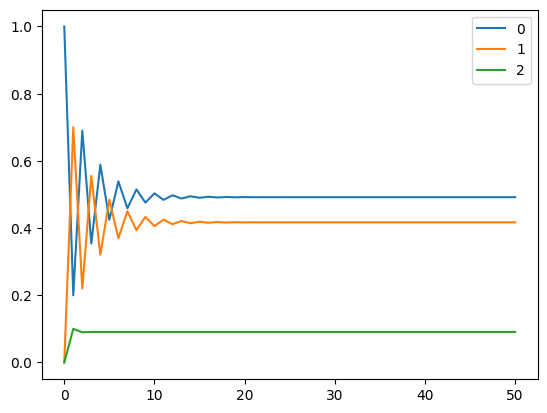

In [19]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt

P = np.array([[0.2, 0.7, 0.1],
              [0.9, 0.0, 0.1],
              [0.2, 0.8, 0.0]])

state=np.array([[1.0, 0.0, 0.0]])

stateHist=state
dfStateHist=pd.DataFrame(state) # Prepara los datos para graficarlos fácilmente como una tabla/serie temporal.

for x in range(50):
    state=np.dot(state,P)
    print(state)
    stateHist=np.append(stateHist,state,axis=0)

dfDistrHist = pd.DataFrame(stateHist)

dfDistrHist.plot()
plt.show()

## Diagramas de estados

Primeramente, copia los archivos src/node.py y src/markovchain.py en tu directorio de trabajo.

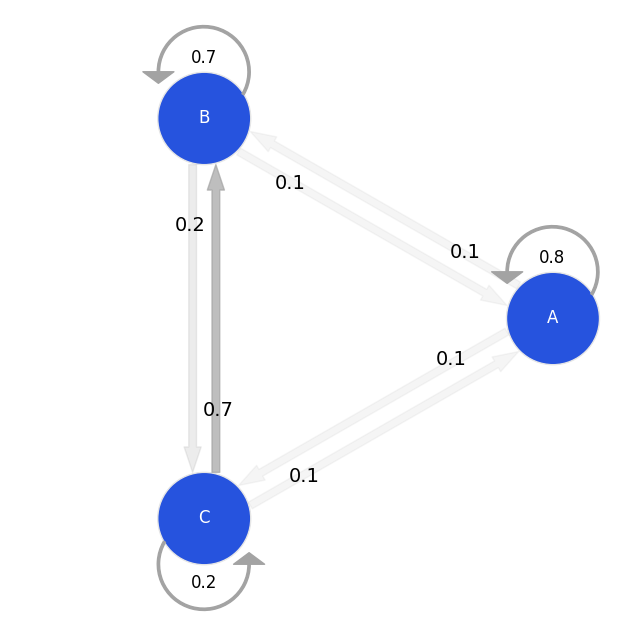

In [20]:
from markovchain import MarkovChain

# Creación de cadena de Markov de tres estados
P = np.array([
    [0.8, 0.1, 0.1],
    [0.1, 0.7, 0.2],
    [0.1, 0.7, 0.2],
])
mc = MarkovChain(P, ['A', 'B', 'C'])
mc.draw()

## EJERCICIOS

1. El ascensor de un edificio con bajo y dos pisos realiza viajes de uno a otro piso. El piso en el que finaliza el viaje n-ésimo del ascensor sigue una cadena de Markov. Se sabe que la mitad de los viajes que parten del bajo se dirigen a cada uno de los otros dos pisos, mientras que si un viaje comienza en el primer piso, sólo el 25% de las veces finaliza en el segundo. Por último, si un trayecto
comienza en el segundo piso, siempre finaliza en el bajo. Se pide: 

    a) Calcular la matriz de probabilidades de transición de la cadena.

    b) Dibujar el gráfico asociado. 

    c) ¿Cuál es la probabilidad de que, a largo plazo, el ascensor se encuentre en cada uno de los tres pisos.

Apartado A - Matriz de Transición (P):
[[0.   0.5  0.5 ]
 [0.75 0.   0.25]
 [1.   0.   0.  ]]


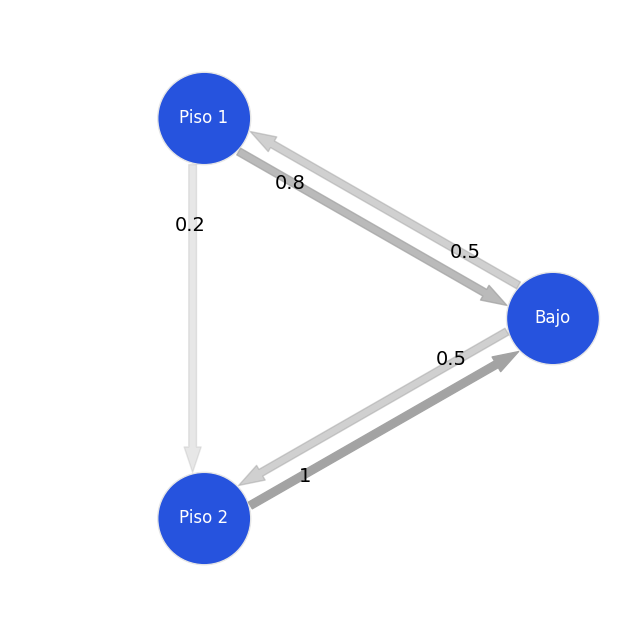


Apartado C - Probabilidades a largo plazo:
Estado Bajo: 0.4706 (47.1%)
Estado Piso 1: 0.2353 (23.5%)
Estado Piso 2: 0.2941 (29.4%)

Conclusión: Es más probable encontrar el ascensor en el Bajo.


In [21]:
import numpy as np
from markovchain import MarkovChain

# --- APARTADO A: Matriz de Transición ---
# Definimos los estados: 0: Bajo, 1: Piso 1, 2: Piso 2
# Probabilidades según el enunciado:
# Bajo -> 50% P1, 50% P2
# Piso 1 -> 25% P2 (el resto, 75%, vuelve al Bajo)
# Piso 2 -> 100% al Bajo
P = np.array([
    [0.00, 0.50, 0.50],
    [0.75, 0.00, 0.25],
    [1.00, 0.00, 0.00]
])

print("Apartado A - Matriz de Transición (P):")
print(P)

# --- APARTADO B: Diagrama de Estados ---
nombres_estados = ['Bajo', 'Piso 1', 'Piso 2']
mc = MarkovChain(P, nombres_estados)
mc.draw()

# --- APARTADO C: Probabilidades a largo plazo ---
# Elevamos la matriz a una potencia alta (n=100) para hallar el estado estacionario
estacionario = np.linalg.matrix_power(P, 100)

print("\nApartado C - Probabilidades a largo plazo:")
for i, nombre in enumerate(nombres_estados):
    prob = estacionario[0][i]
    print(f"Estado {nombre}: {prob:.4f} ({prob*100:.1f}%)")

# Respuesta a la pregunta del enunciado:
max_prob_idx = np.argmax(estacionario[0])
print(f"\nConclusión: Es más probable encontrar el ascensor en el {nombres_estados[max_prob_idx]}.")

2. Hay tres empresas que venden conexión a Internet basada en fibra a los hogares de los clientes. Estas empresas llevan aquí bastante tiempo y los clientes también cambian de empresa según los siguientes datos: 

    a) El 10% de los clientes de Hathway cambiarán a ADN y el 10% a Excitel. 

    b) El 20% de los clientes de ADN se cambiarán a Hathway y el 20% a Excitel. 

    c) El 10% de los clientes de Excitel se pasarán a Hathway y el 20% a ADN. 

    Dibuja el diagrama de transición asociado y averigua el porcentaje de fidelidad que los clientes mantendrán con cada una de las empresas.

Apartado A - Matriz de Transición (P):
[[0.8 0.1 0.1]
 [0.2 0.6 0.2]
 [0.1 0.2 0.7]]


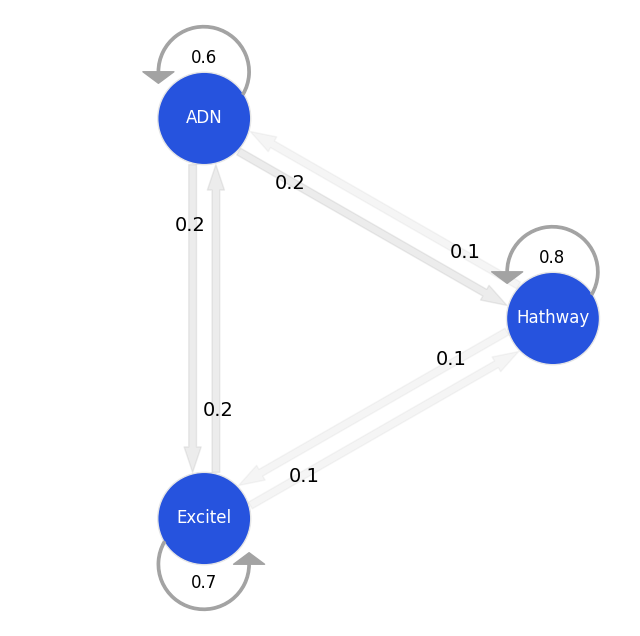


Apartado C - Fidelidad a largo plazo (Estado Estacionario):
Hathway: 0.4211 (42.1%)
ADN: 0.2632 (26.3%)
Excitel: 0.3158 (31.6%)

Conclusión: La empresa con mayor fidelidad a largo plazo es Hathway.


In [22]:
import numpy as np
from markovchain import MarkovChain

# --- APARTADO A: Matriz de Transición ---
# Estados: 0: Hathway (H), 1: ADN (A), 2: Excitel (E)
# H: Retiene 80%, va 10% a A y 10% a E
# A: Retiene 60%, va 20% a H y 20% a E
# E: Retiene 70%, va 10% a H y 20% a A
P_fibra = np.array([
    [0.8, 0.1, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.2, 0.7]
])

print("Apartado A - Matriz de Transición (P):")
print(P_fibra)

# --- APARTADO B: Diagrama de Estados ---
nombres_fibra = ['Hathway', 'ADN', 'Excitel']
mc_fibra = MarkovChain(P_fibra, nombres_fibra)
mc_fibra.draw()

# --- APARTADO C: Fidelidad a largo plazo ---
# Calculamos el estado estacionario elevando la matriz
estacionario_fibra = np.linalg.matrix_power(P_fibra, 100)

print("\nApartado C - Fidelidad a largo plazo (Estado Estacionario):")
for i, nombre in enumerate(nombres_fibra):
    fidelidad = estacionario_fibra[0][i]
    print(f"{nombre}: {fidelidad:.4f} ({fidelidad*100:.1f}%)")

# Determinamos cuál tiene mayor fidelidad
mejor_idx = np.argmax(estacionario_fibra[0])
print(f"\nConclusión: La empresa con mayor fidelidad a largo plazo es {nombres_fibra[mejor_idx]}.")

3. Hay tres empresas que venden software antivirus: Mcaffe, Quickheal y Kaspersky. A estas tres empresas les iba muy bien, pero una nueva empresa, Avira, entra en el mercado y diseña e implementa estrategias de marketing que demuestran que atraerá a: el 5% de los usuarios de KASPERSKEY, al 2% de la base de clientes de MCAFFE, el 6% de los usuarios de QUICK. Además, KASPERSKEY retiene al 92% de sus clientes, MCAFEE al 94%, QUICK el 90% y la nueva compañia retendrá al 97% de sus usuarios. Basándonos en esto, dibuja el diagrama de transición asociado y desarra un modelo para predecir la cuota de mercado.

Apartado A - Matriz de Transición (P):
[[0.7 0.2 0.1]
 [0.1 0.8 0.1]
 [0.  0.  1. ]]


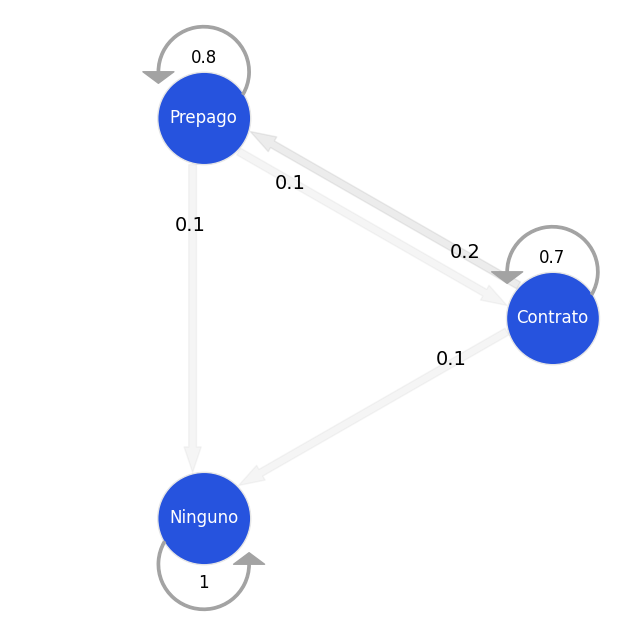


Apartado C - Probabilidades a largo plazo:
Contrato: 0.0000
Prepago: 0.0000
Ninguno: 1.0000

Conclusión: El estado 'Ninguno' es un estado absorbente.
A largo plazo, el 100% de los usuarios terminarán dándose de baja.


In [23]:
import numpy as np
from markovchain import MarkovChain

# --- APARTADO A: Matriz de Transición ---
# Estados: 0: Contrato, 1: Prepago, 2: Ninguno (Baja)
# Contrato: 70% sigue, 20% pasa a Prepago, 10% se da de baja
# Prepago: 80% sigue, 10% pasa a Contrato, 10% se da de baja
# Ninguno: 100% se queda en baja (Estado absorbente según el enunciado)
P_telefonia = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.8, 0.1],
    [0.0, 0.0, 1.0]
])

print("Apartado A - Matriz de Transición (P):")
print(P_telefonia)

# --- APARTADO B: Diagrama de Estados ---
nombres_telefonia = ['Contrato', 'Prepago', 'Ninguno']
mc_telefonia = MarkovChain(P_telefonia, nombres_telefonia)
mc_telefonia.draw()

# --- APARTADO C: Probabilidades a largo plazo ---
# Calculamos el estado estacionario
estacionario_telefonia = np.linalg.matrix_power(P_telefonia, 100)

print("\nApartado C - Probabilidades a largo plazo:")
for i, nombre in enumerate(nombres_telefonia):
    prob = estacionario_telefonia[0][i]
    print(f"{nombre}: {prob:.4f}")

# Conclusión técnica:
print("\nConclusión: El estado 'Ninguno' es un estado absorbente.")
print("A largo plazo, el 100% de los usuarios terminarán dándose de baja.")

4. La siguiente matriz de transición de probabilidades se ha tomado de los datos de las agencias de calificación crediticia como Standard & Poor, Moody's y Fitch en los sectores financieros e industriual. Esta matriz, describe las probabilidades de transición de que una determinada empresa, país, etc. permanezca en su estado actual, o pase a un nuevo estado. Basándonos en esto, dibuja el diagrama de transición y desarra un modelo para predecir la evolución.

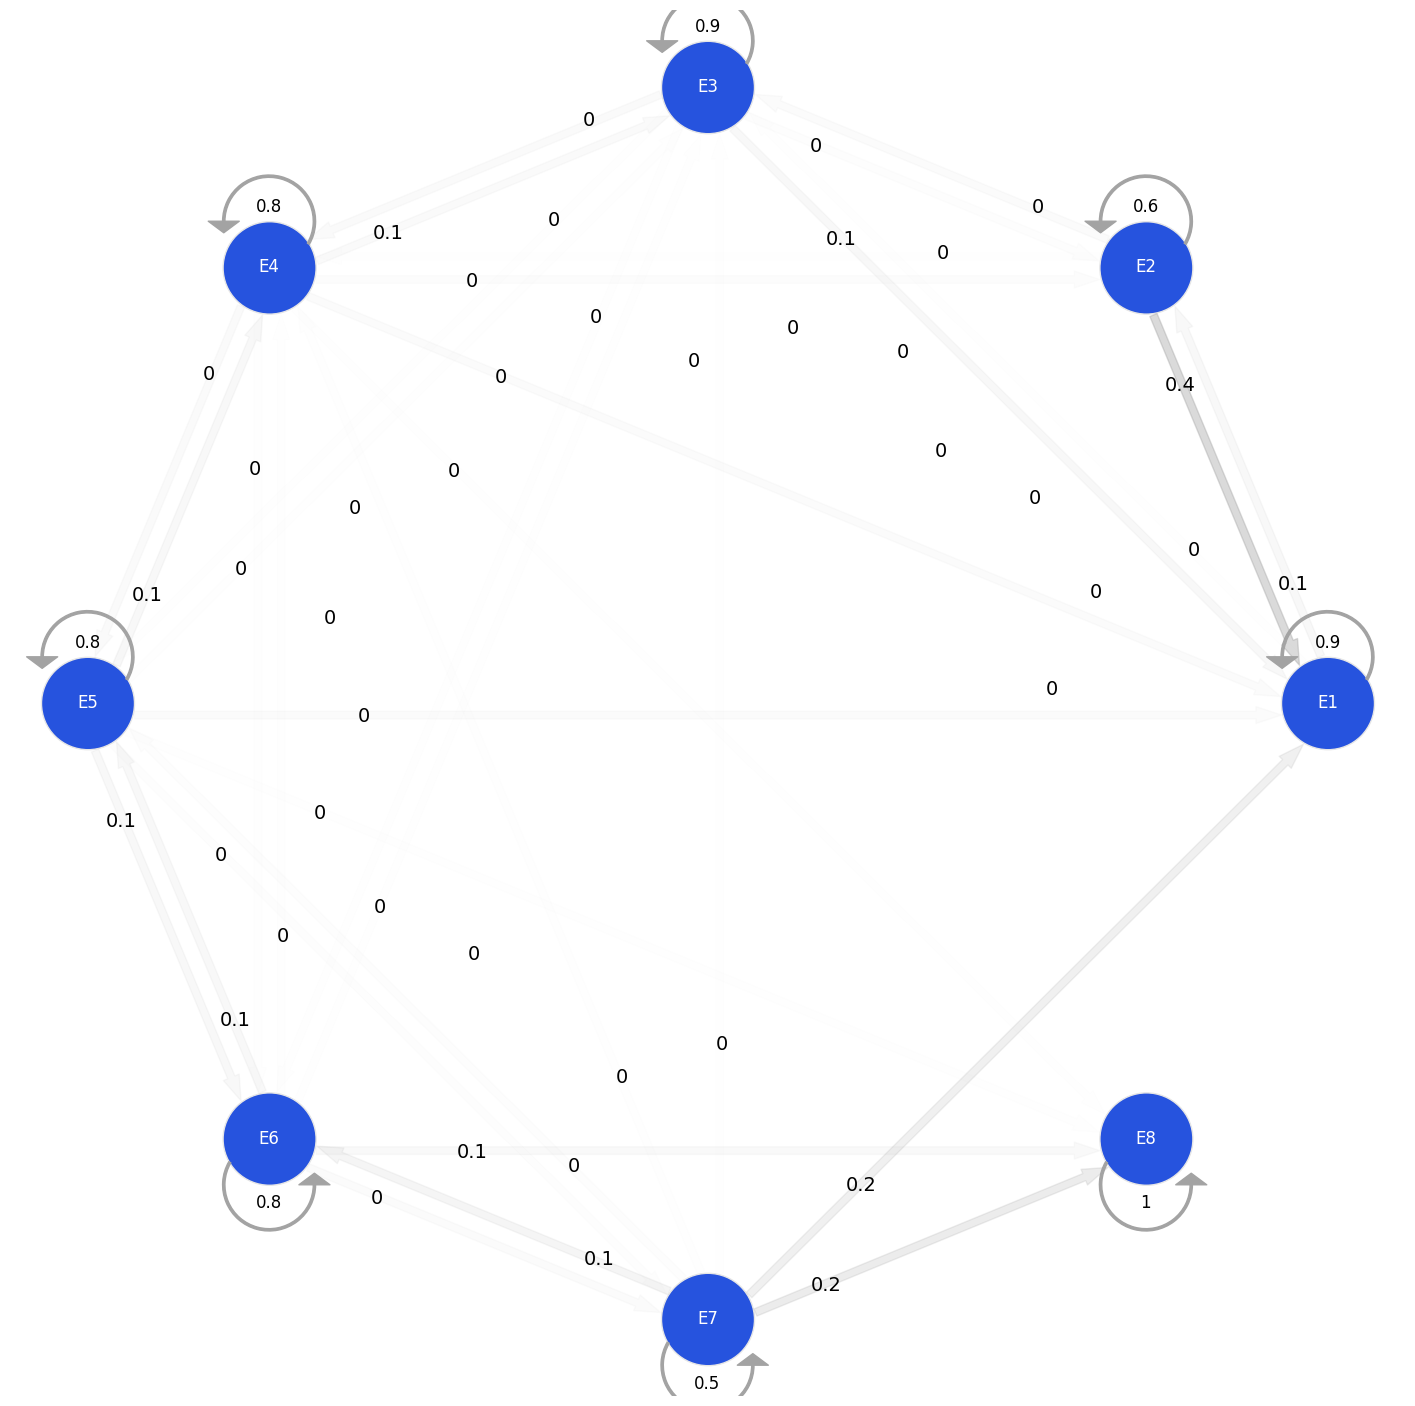

Modelo de predicción de evolución tras 10 periodos:
[[0.785 0.139 0.053 0.015 0.004 0.002 0.    0.001]
 [0.751 0.134 0.075 0.025 0.007 0.004 0.001 0.003]
 [0.442 0.088 0.27  0.122 0.038 0.022 0.003 0.015]
 [0.357 0.074 0.145 0.215 0.091 0.059 0.008 0.049]
 [0.256 0.048 0.067 0.141 0.165 0.147 0.018 0.157]
 [0.123 0.021 0.028 0.065 0.129 0.225 0.027 0.381]
 [0.295 0.051 0.026 0.027 0.042 0.07  0.009 0.48 ]
 [0.    0.    0.    0.    0.    0.    0.    1.   ]]


In [24]:
import numpy as np
from markovchain import MarkovChain

# Definición de la matriz P según el enunciado
P = np.array([
    [0.9193, 0.0746, 0.0048, 0.0008, 0.0004, 0.0000, 0.0000, 0.0000],
    [0.3917, 0.5619, 0.0414, 0.0037, 0.0004, 0.0007, 0.0002, 0.0000], 
    [0.0655, 0.0212, 0.8574, 0.0479, 0.0052, 0.0023, 0.0001, 0.0004], 
    [0.0376, 0.0254, 0.0522, 0.8256, 0.0454, 0.0096, 0.0016, 0.0023], 
    [0.0385, 0.0010, 0.0059, 0.0746, 0.7838, 0.0760, 0.0107, 0.0097], 
    [0.0000, 0.0010, 0.0028, 0.0046, 0.0695, 0.8280, 0.0396, 0.0545], 
    [0.1600, 0.0000, 0.0031, 0.0063, 0.0205, 0.1021, 0.5088, 0.1993], 
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000] 
])

# 1. Dibujar el diagrama de transición
estados = ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8']
mc = MarkovChain(P, estados)
mc.draw()

# 2. Modelo para predecir la evolución
# El modelo predice el estado futuro Vt multiplicando el estado inicial V0 por P elevado a t.
# Ejemplo: Evolución a 10 periodos (años)
t = 10
P_evolucion = np.linalg.matrix_power(P, t)

print(f"Modelo de predicción de evolución tras {t} periodos:")
print(P_evolucion)

# Nota: El estado E8 es absorbente (probabilidad 1.0), lo que indica 'Default' o quiebra. 
# A largo plazo, el modelo predice que los estados tenderán hacia E8.

5. En una comunidad hay 3 supermercados (S1, S2, S3) existe la movilidad de un cliente de uno a otro. El 1 de septiembre, ¼ de los clientes va al S1, 1/3 al S2 y 5/12 al S3 de un total de 10.000 personas. Cada mes el S1 retiene el 90% de sus clientes y pierde el 10% que se va al S2. Se averiguó que el S2 solo retiene el 5% y pierde el 85% que va a S1 y el resto se va a S3, el S3 retiene solo el 40%, pierde el 50% que va al S1 y el 10% va al S2. Calcula: 
    
    a) La matriz de transición (representala). 
    
    b) ¿Cuál es la proporción de clientes para los supermercados el 1 de noviembre?. 
    
    c) Hallar el vector de probabilidad estable.

Apartado A - Matriz de Transición:
[[0.9  0.1  0.  ]
 [0.85 0.05 0.1 ]
 [0.5  0.1  0.4 ]]


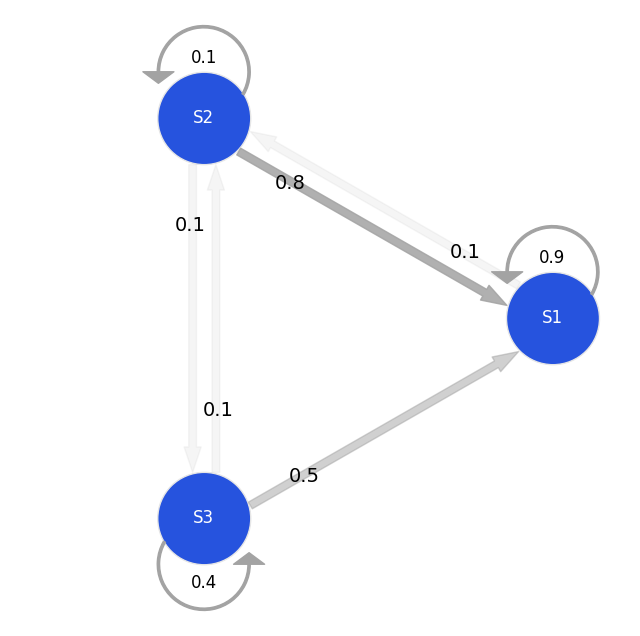


Apartado B - Distribución al 1 de noviembre:
S1: 0.8158 (8158 personas)
S2: 0.0958 (958 personas)
S3: 0.0883 (883 personas)

Apartado C - Vector de probabilidad estable:
S1: 0.8889
S2: 0.0952
S3: 0.0159


In [25]:
import numpy as np
from markovchain import MarkovChain

# --- APARTADO A: Matriz de Transición ---
# S1: 90% se queda, 10% a S2, 0% a S3
# S2: 85% a S1, 5% se queda, 10% a S3
# S3: 50% a S1, 10% a S2, 40% se queda
P_super = np.array([
    [0.90, 0.10, 0.00],
    [0.85, 0.05, 0.10],
    [0.50, 0.10, 0.40]
])

print("Apartado A - Matriz de Transición:")
print(P_super)

# Dibujamos el diagrama
nombres_super = ['S1', 'S2', 'S3']
mc_super = MarkovChain(P_super, nombres_super)
mc_super.draw()

# --- APARTADO B: Proporción el 1 de noviembre (2 meses) ---
# Vector inicial V0 (1 de septiembre)
v0 = np.array([1/4, 1/3, 5/12])
total_personas = 10000

# Calculamos V2 = V0 * P^2
P2 = np.linalg.matrix_power(P_super, 2)
v2 = np.dot(v0, P2)

print("\nApartado B - Distribución al 1 de noviembre:")
for i, nombre in enumerate(nombres_super):
    print(f"{nombre}: {v2[i]:.4f} ({int(v2[i] * total_personas)} personas)")

# --- APARTADO C: Vector de probabilidad estable ---
estacionario_super = np.linalg.matrix_power(P_super, 100)
v_estable = estacionario_super[0]

print("\nApartado C - Vector de probabilidad estable:")
for i, nombre in enumerate(nombres_super):
    print(f"{nombre}: {v_estable[i]:.4f}")

6. Supongamos una cola para comprar un billete en un mostrador de una línea aerea. Se sabe que: 

    a) En un intervalo de un minuto, hay una probabilidad de 1/3 de que una persona se añada a la cola y una probabilidad de 2/3 de que nadie se agregue. Además, observemos, que en cualquier intervalo de un minuto nunca se agregará más de una persona a la cola. 

    b) Si se está atendiendo a una persona en un intervalo, la probabilidad de que en ese mismo intervalo reciba el billete es de 3/8. Si es así, saldrá de la cola en el siguiente intervalo. 

    c) Todas las probabilidades son independientes de lo que haya sucedido en intervalos anteriores. 
    
    d) Una persona no puede ser atendida en el mismo intervalo en que llega a la cola. 
    
    e)  No pueden ser atendidas más de una persona en un mismo intervalo. 
    
    f) Como media para que no se congestiones la cola, se cerrará si hay 4 personas esperando en ella. Es decir, como mucho, nuestra cola puede tener 4 personas. Calcula La matriz de transición y representala. Hallar el vector de probabilidad estable.

Apartado A - Matriz de Transición:
[[0.667 0.333 0.    0.    0.   ]
 [0.25  0.542 0.208 0.    0.   ]
 [0.    0.25  0.542 0.208 0.   ]
 [0.    0.    0.25  0.542 0.208]
 [0.    0.    0.    0.375 0.625]]


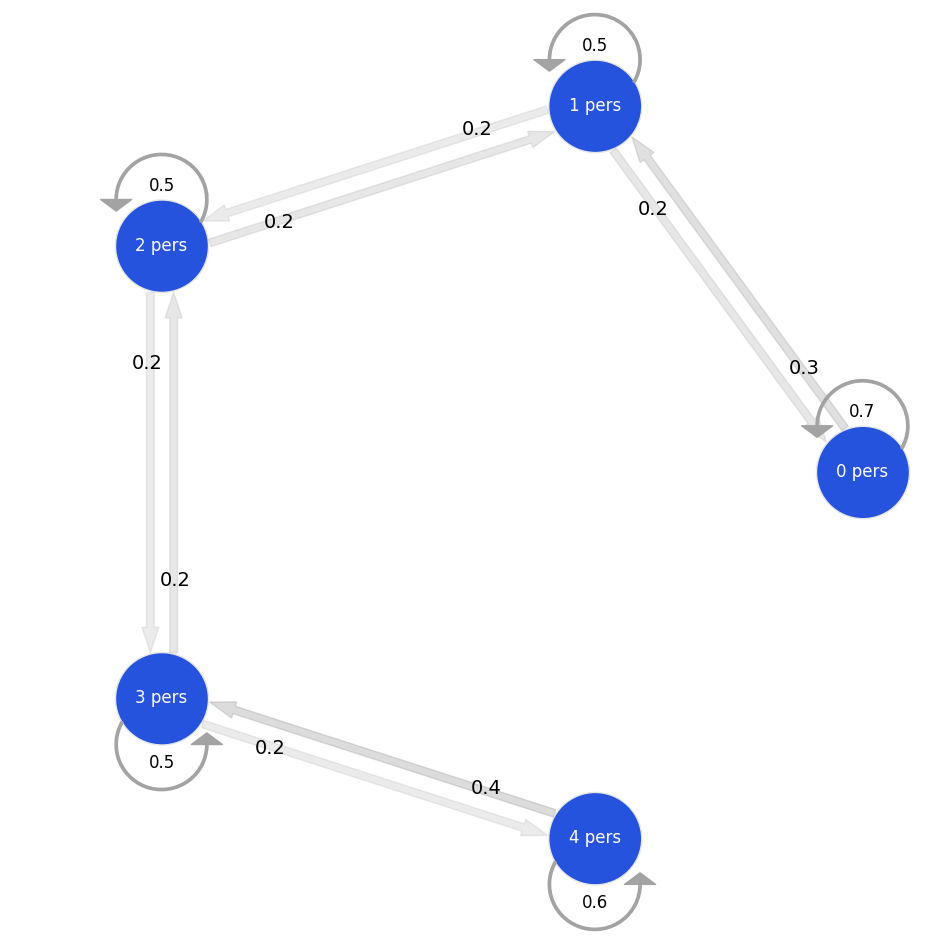


Vector de probabilidad estable:
0 pers: 0.2047
1 pers: 0.2730
2 pers: 0.2275
3 pers: 0.1896
4 pers: 0.1053

Conclusión: La situación más probable es tener 1 pers.


In [26]:
import numpy as np
from markovchain import MarkovChain

# --- APARTADO A: Matriz de Transición ---
# Probabilidades base:
# P(llegada) = 1/3, P(no llegada) = 2/3
# P(salida) = 3/8, P(no salida) = 5/8 (solo si hay gente > 0)

# Construimos la matriz 5x5 (estados: 0, 1, 2, 3, 4 personas)
P_cola = np.array([
    [2/3, 1/3, 0, 0, 0],                            # Estado 0: Solo puede llegar alguien
    [1/4, 13/24, 5/24, 0, 0],                       # Estado 1: (1/4=no lleg.*salida, 13/24=ambos o ninguno, 5/24=lleg.*no sal.)
    [0, 1/4, 13/24, 5/24, 0],                       # Estado 2
    [0, 0, 1/4, 13/24, 5/24],                       # Estado 3
    [0, 0, 0, 3/8, 5/8]                             # Estado 4: Límite (llegadas bloqueadas)
])

print("Apartado A - Matriz de Transición:")
print(P_cola)

# Dibujar el diagrama
nombres_cola = ['0 pers', '1 pers', '2 pers', '3 pers', '4 pers']
mc_cola = MarkovChain(P_cola, nombres_cola)
mc_cola.draw()

# --- APARTADO B: Vector de probabilidad estable ---
estacionario_cola = np.linalg.matrix_power(P_cola, 100)
v_estable = estacionario_cola[0]

print("\nVector de probabilidad estable:")
for i, nombre in enumerate(nombres_cola):
    print(f"{nombre}: {v_estable[i]:.4f}")

# Conclusión
print(f"\nConclusión: La situación más probable es tener {nombres_cola[np.argmax(v_estable)]}.")